# 47. Which way a magnet turns, when it is free to

Notebook 36 asks which of a few chosen directions a magnet prefers. Here the
magnet is let go and turns on its own: every spin in the cell is turned by one
rotation, the torque on the whole texture is computed, and the orientation is
moved downhill along it until the torque vanishes, exactly as atoms are moved
along their forces until they stop. What comes out is the easy axis of a
ferromagnet, or, for a spiral in a supercell, the plane it lies in.

Tetragonal cobalt started 51.6 degrees away from its long axis lands on it in
**eight steps**, and the energy it gains on the way traces
`K1 sin^2(theta) + K2 sin^4(theta)` with **K1 = 0.54 meV**, the same constant
notebook 36 gets from the difference between two directions. Quantum ESPRESSO
computes the energy of one direction at a time (`lforcet`), and neither it nor
Elk turns a magnet by its torque.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from defumat import Calculator
from defumat.workflows.anisotropy import rotation_from_euler   # no facade route to a rotation from angles

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

scalar = Calculator.from_file(CASES / "co-tetragonal-anisotropy-sr.in", PSEUDO,
                              announce=False)
spinor = Calculator.from_file(CASES / "co-tetragonal-anisotropy-soc.in", PSEUDO,
                              announce=False)
scf = scalar.get_scf()

## The torque on the whole magnet

The magnet is converged once without spin-orbit coupling. Turning its moment and
diagonalising once with the coupling gives the energy of that orientation, and
the torque is its derivative with respect to the three ways the moment can be
turned, taken of the energy itself rather than derived by hand. With the moment
45 degrees from `c` towards `a`, the only torque is the one about `b` that turns
it back towards `c`, and for `E = K1 sin^2(theta)` its size at 45 degrees is
`K1`.

In [2]:
tilted = rotation_from_euler(0.0, np.pi / 4, 0.0)       # c tilted 45 degrees
vector = scalar.get_orientation_torque(spinor, rotation=tilted)

RY_TO_MEV = 13605.693
print("torque (meV/rad):", np.round(vector.torque * RY_TO_MEV, 5))
print("about the moment itself:", f"{vector.along_moment * RY_TO_MEV:.1e} meV/rad")

torque (meV/rad): [ 0.      -0.55232 -0.     ]
about the moment itself: -3.8e-18 meV/rad


The torque about the moment itself is zero, because turning a moment about
its own direction moves nothing. That leaves two ways to turn a single moment,
and the relaxation below moves in both.

## Letting it turn

The start is deliberately off every symmetry of the crystal: an orientation a
symmetry fixes feels no torque, whether it is the easy axis or the hard one, so
a relaxation started there would stop at once.

In [3]:
start = rotation_from_euler(0.4, 0.9, -0.3)             # 51.6 degrees off c
relaxed = scalar.get_relaxed_orientation(spinor, rotation=start)

theta = np.degrees([np.arccos(abs(step.direction[2])) for step in relaxed.steps])
energy = (relaxed.free_energies - relaxed.free_energies[-1]) * RY_TO_MEV
for step, angle, e in zip(relaxed.steps, theta, energy):
    print(f"step {step.index}: {angle:7.3f} degrees from c, {e:8.5f} meV above the end")
print("ends along", np.round(relaxed.direction, 5))

step 1:  51.566 degrees from c,  0.33464 meV above the end
step 2:  40.108 degrees from c,  0.22542 meV above the end
step 3:  27.503 degrees from c,  0.11535 meV above the end
step 4:   8.595 degrees from c,  0.01204 meV above the end
step 5:   1.948 degrees from c,  0.00062 meV above the end
step 6:   0.036 degrees from c,  0.00000 meV above the end
step 7:   0.018 degrees from c,  0.00000 meV above the end
step 8:   0.008 degrees from c,  0.00000 meV above the end
ends along [-1.1e-04  9.0e-05  1.0e+00]


## The same, inside a self-consistent run with the coupling

A calculation that already has spin-orbit coupling is free to turn its moments
itself, and in principle it relaxes the orientation along the way. In practice
it barely does: the push on the orientation is the anisotropy, a millionth of
the energies the self-consistent loop is balancing, and started 45 degrees off
`c` the moment wanders and the run does not settle. Turning the moments by the
same torque after every step of the loop fixes that.

In [4]:
text = (CASES / "co-tetragonal-relaxed-mae.in").read_text()
oblique = text.replace("angle1(1) = 0.0", "angle1(1) = 45.0")

def angles(result):
    m = np.array([entry["magnetization_vector"] for entry in result.history])
    return np.degrees(np.arccos(np.abs(m[:, 2]) / np.linalg.norm(m, axis=1)))

plain = Calculator.from_text(oblique, PSEUDO, announce=False).get_scf(max_iterations=100)
turned = Calculator.from_text(oblique, PSEUDO, announce=False).get_scf(
    rotate_moments=True, conv_thr=1e-12, torque_conv_thr=1e-9)
along = Calculator.from_text(text, PSEUDO, announce=False).get_scf(conv_thr=1e-12)

print(f"plain:   converged {plain.converged}, ends {angles(plain)[-1]:.2f} degrees from c")
print(f"turned:  converged {turned.converged} in {turned.iterations} iterations, "
      f"ends {angles(turned)[-1]:.4f} degrees from c")
print(f"energy against a run started along c: {turned.total_energy - along.total_energy:.1e} Ry")

/u/40/ladovj1/data/Documents/programs/claude/defumat/defumat/calculator.py:756: RuntimeWarning: the SCF stopped without converging: 100 iterations reached accuracy = 6.117e-06 Ry against conv_thr = 1.000e-10. Every quantity on this result is computed from an unconverged density. Raise electron_maxstep, change the mixing (a smaller mixing_beta for a run that is oscillating; mixing_mode = 'adaptive' for one that is crawling, where mixing_beta means an increment and a smaller one is the wrong reflex), or start from a better density (run_scf(starting_from=...)); SCFResult.converged and .accuracy are what say which this is
  self._scf = run_scf(self.system, self.pseudos,


plain:   converged False, ends 36.51 degrees from c
turned:  converged True in 44 iterations, ends 0.0023 degrees from c
energy against a run started along c: 1.3e-08 Ry


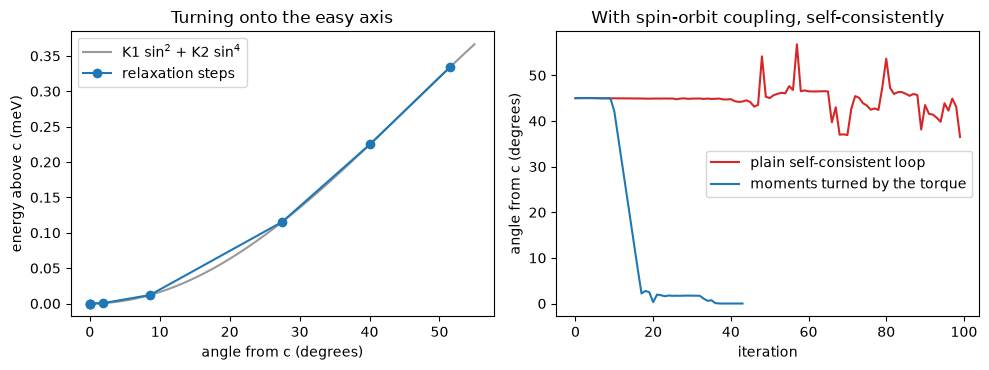

In [5]:
sin2 = np.sin(np.radians(theta)) ** 2
k1, k2 = np.linalg.lstsq(np.stack([sin2, sin2 ** 2], axis=1), energy - energy.min(),
                         rcond=None)[0]
grid = np.linspace(0, 55, 200)
s2 = np.sin(np.radians(grid)) ** 2

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.8))
left.plot(grid, k1 * s2 + k2 * s2 ** 2, color="0.6", label="K1 sin$^2$ + K2 sin$^4$")
left.plot(theta, energy - energy.min(), "o-", color="C0", label="relaxation steps")
left.set(xlabel="angle from c (degrees)", ylabel="energy above c (meV)",
         title="Turning onto the easy axis")
left.legend()
right.plot(angles(plain), color="C3", label="plain self-consistent loop")
right.plot(angles(turned), color="C0", label="moments turned by the torque")
right.set(xlabel="iteration", ylabel="angle from c (degrees)",
          title="With spin-orbit coupling, self-consistently")
right.legend()
fig.tight_layout()

On the left, the energy along the relaxation lies on a two-constant curve,
and the fit reads the anisotropy constants off the path itself. On the right,
the plain loop drifts back and forth between about 36 and 54 degrees without
converging, while the loop that turns its moments reaches `c` and stops.

In [6]:
torque_k = -vector.torque[1] * RY_TO_MEV                 # K1 + K2 at 45 degrees
print(f"{'':42s}{'meV':>8s}")
print(f"{'K1, from the energy along the path':42s}{k1:8.4f}")
print(f"{'K2, from the energy along the path':42s}{k2:8.4f}")
print(f"{'K1 + K2, from the torque at 45 degrees':42s}{torque_k:8.4f}")
print(f"{'K1 + K2, from the path fit':42s}{k1 + k2:8.4f}")

                                               meV
K1, from the energy along the path          0.5385
K2, from the energy along the path          0.0111
K1 + K2, from the torque at 45 degrees      0.5523
K1 + K2, from the path fit                  0.5497


The torque at 45 degrees measures `K1 + K2` (the second term's slope there
is `K2`), and the path fit gives the same sum from energies alone, a check that
shares nothing with the derivative.

## How it works

What turns the magnet is the exchange field acting on the magnetization of the
states once spin-orbit coupling is switched on. Without the coupling the
magnetization the states produce points exactly along the exchange field that
made them, and nothing turns. With it, the orbital motion drags the spins a
little off that field, towards the directions the crystal prefers, and the lean
between the two is the torque: the integral of the magnetization crossed with
the exchange field. The same lean is present in every step of a self-consistent
loop with the coupling, which is why the loop can be made to follow it.

*The checks behind these numbers are in `tests/regression/test_anisotropy.py`
and `tests/unit/test_orientation_torque.py`.*